In [1]:
import pandas as pd
from IPython.display import display, HTML
from IPython.core.interactiveshell import InteractiveShell
import seaborn as sns
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
InteractiveShell.ast_node_interactivity = "all"

In [2]:
%autosave 0

Autosave disabled


In [3]:
df = pd.read_csv(r"C:\Users\Decagon Laptop\Documents\Retail-feedback-shipping-analysis\new_retail_data.csv~1\new_retail_data.csv")
df

,Transaction_ID,Customer_ID,Name,Email,Phone,Address,City,State,Zipcode,Country,...,Total_Amount,Product_Category,Product_Brand,Product_Type,Feedback,Shipping_Method,Payment_Method,Order_Status,Ratings,products
0,8691788.0,37249.0,Michelle Harrington,Ebony39@gmail.com,1.414787e+09,3959 Amanda Burgs,Dortmund,Berlin,77985.0,Germany,...,324.086270,Clothing,Nike,Shorts,Excellent,Same-Day,Debit Card,Shipped,5.0,Cycling shorts
1,2174773.0,69749.0,Kelsey Hill,Mark36@gmail.com,6.852900e+09,82072 Dawn Centers,Nottingham,England,99071.0,UK,...,806.707815,Electronics,Samsung,Tablet,Excellent,Standard,Credit Card,Processing,4.0,Lenovo Tab
2,6679610.0,30192.0,Scott Jensen,Shane85@gmail.com,8.362160e+09,4133 Young Canyon,Geelong,New South Wales,75929.0,Australia,...,1063.432799,Books,Penguin Books,Children's,Average,Same-Day,Credit Card,Processing,2.0,Sports equipment
3,7232460.0,62101.0,Joseph Miller,Mary34@gmail.com,2.776752e+09,8148 Thomas Creek Suite 100,Edmonton,Ontario,88420.0,Canada,...,2466.854021,Home Decor,Home Depot,Tools,Excellent,Standard,PayPal,Processing,4.0,Utility knife
4,4983775.0,27901.0,Debra Coleman,Charles30@gmail.com,9.098268e+09,5813 Lori Ports Suite 269,Bristol,England,48704.0,UK,...,248.553049,Grocery,Nestle,Chocolate,Bad,Standard,Cash,Shipped,1.0,Chocolate cookies
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
302005,4246475.0,12104.0,Meagan Ellis,Courtney60@gmail.com,7.466354e+09,389 Todd Path Apt. 159,Townsville,New South Wales,4567.0,Australia,...,973.962984,Books,Penguin Books,Fiction,Bad,Same-Day,Cash,Processing,1.0,Historical fiction
302006,1197603.0,69772.0,Mathew Beck,Jennifer71@gmail.com,5.754305e+09,52809 Mark Forges,Hanover,Berlin,16852.0,Germany,...,285.137301,Electronics,Apple,Laptop,Excellent,Same-Day,Cash,Processing,5.0,LG Gram
302007,7743242.0,28449.0,Daniel Lee,Christopher100@gmail.com,9.382530e+09,407 Aaron Crossing Suite 495,Brighton,England,88038.0,UK,...,182.105285,Clothing,Adidas,Jacket,Average,Express,Cash,Shipped,2.0,Parka
302008,9301950.0,45477.0,Patrick Wilson,Rebecca65@gmail.com,9.373222e+09,3204 Baird Port,Halifax,Ontario,67608.0,Canada,...,120.834784,Home Decor,IKEA,Furniture,Good,Standard,Cash,Shipped,4.0,TV stand


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302010 entries, 0 to 302009
Data columns (total 30 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction_ID    301677 non-null  float64
 1   Customer_ID       301702 non-null  float64
 2   Name              301628 non-null  object 
 3   Email             301663 non-null  object 
 4   Phone             301648 non-null  float64
 5   Address           301695 non-null  object 
 6   City              301762 non-null  object 
 7   State             301729 non-null  object 
 8   Zipcode           301670 non-null  float64
 9   Country           301739 non-null  object 
 10  Age               301837 non-null  float64
 11  Gender            301693 non-null  object 
 12  Income            301720 non-null  object 
 13  Customer_Segment  301795 non-null  object 
 14  Date              301651 non-null  object 
 15  Year              301660 non-null  float64
 16  Month             30

In [5]:
df.describe()

,Transaction_ID,Customer_ID,Phone,Zipcode,Age,Year,Total_Purchases,Amount,Total_Amount,Ratings
count,3.016770e+05,301702.000000,3.016480e+05,301670.000000,301837.000000,301660.000000,301649.000000,301653.000000,301660.000000,301826.000000
mean,5.495823e+06,55006.553934,5.501464e+09,50298.951019,35.481326,2023.165113,5.359729,255.163659,1367.651156,3.162670
std,2.595565e+06,26005.675200,2.596017e+09,28972.807134,15.021933,0.371283,2.868575,141.389640,1128.998515,1.320827
min,1.000007e+06,10000.000000,1.000049e+09,501.000000,18.000000,2023.000000,1.000000,10.000219,10.003750,1.000000
25%,3.247930e+06,32469.250000,3.255061e+09,25425.000000,22.000000,2023.000000,3.000000,132.890764,438.724278,2.000000
50%,5.499657e+06,55012.000000,5.505812e+09,50602.500000,32.000000,2023.000000,5.000000,255.470969,1041.117547,3.000000
75%,7.739509e+06,77511.000000,7.749860e+09,75252.000000,46.000000,2023.000000,8.000000,377.672606,2029.999853,4.000000
max,9.999995e+06,99999.000000,9.999996e+09,99949.000000,70.000000,2024.000000,10.000000,499.997911,4999.625796,5.000000


# Preparing The Data

In [6]:
# 1. Fill missing values
# For numeric columns, replace missing values with the median
numeric_columns = df.select_dtypes(include=["float64", "int64"]).columns
df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].median())

# For text/categorical columns, replace missing values with the most common value (mode)
categorical_columns = df.select_dtypes(include=["object"]).columns
for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# 2. Remove any duplicate rows in the dataset
df = df.drop_duplicates()

# 3. Clean up all text values in categorical columns
# Strip extra spaces and make capitalization consistent
for col in categorical_columns:
    df.loc[:, col] = df[col].str.strip().str.title()

# 4. Remove outliers from numeric columns using the IQR method
for col in numeric_columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Keep only values inside the allowed range
    df = df.loc[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

# 5. Clean up column names
# Convert to lowercase and replace spaces with underscores
df.columns = [col.strip().replace(" ", "_").lower() for col in df.columns]

# Check remaining missing values
missing_values = df.isnull().sum()

# Create a summary dictionary
summary = {
    "missing_values": missing_values.sum(),
    "total_rows": len(df),
    "duplicate_rows": df.duplicated().sum(),
    "numeric_columns": numeric_columns.tolist(),
    "categorical_columns": categorical_columns.tolist(),
}

# Save the cleaned dataset
cleaned_data_path = "cleaned_new_retail_data.csv"
df.to_csv(cleaned_data_path, index=False)
print(f"Cleaned data saved to {cleaned_data_path}")

Cleaned data saved to cleaned_new_retail_data.csv


# Hypothesis 1

# Data Exploration

In [7]:
# Select only the relevant columns and remove any rows with missing values
filtered_data = df[["age", "product_category", "total_purchases", "ratings"]].dropna()

# Keep only customers with ratings 4.5 or higher
# .copy() prevents Pandas "chained assignment" warnings
filtered_data = filtered_data[filtered_data["ratings"] >= 4.5].copy()

# Define age ranges (bins) and their corresponding labels
bins = [18, 25, 35, 45, 55, 65, 70]
labels = ["18-25", "26-35", "36-45", "46-55", "56-65", "66-70"]

# Create a new column "age_group" by categorizing ages into the bins above
filtered_data["age_group"] = pd.cut(
    filtered_data["age"],
    bins=bins,
    labels=labels,
    right=True   # include the right edge of each interval
)

# Show the filtered data and count of missing values
print(filtered_data)
print(filtered_data.isnull().sum())

# Fill any missing age_group values with the most common age group (the mode)
filtered_data["age_group"] = filtered_data["age_group"].fillna(
    filtered_data["age_group"].mode()[0]
)

# Confirm that missing values are now handled
print(filtered_data.isnull().sum())

         age product_category  total_purchases  ratings age_group
0       21.0         Clothing              3.0      5.0     18-25
28      43.0       Home Decor              8.0      5.0     36-45
32      66.0       Home Decor              7.0      5.0     66-70
43      46.0       Home Decor              2.0      5.0     46-55
46      57.0       Home Decor              7.0      5.0     56-65
...      ...              ...              ...      ...       ...
301972  53.0      Electronics              3.0      5.0     46-55
301994  18.0          Grocery              1.0      5.0       NaN
301999  55.0      Electronics              8.0      5.0     46-55
302002  63.0       Home Decor              6.0      5.0     56-65
302006  35.0      Electronics              1.0      5.0     26-35

[41444 rows x 5 columns]
age                   0
product_category      0
total_purchases       0
ratings               0
age_group           376
dtype: int64
age                 0
product_category    0
total

age_group
18-25    60767.0
26-35    28719.0
36-45    20691.0
46-55    77596.0
56-65    20753.0
66-70     9950.0
Name: total_purchases, dtype: float64


C:\Users\Decagon Laptop\AppData\Local\Temp\ipykernel_15564\1537405678.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_high_rated = high_rated_products.groupby('age_group')['total_purchases'].sum()


<Axes: xlabel='age_group'>

Text(0.5, 1.0, 'Total Purchase Amount of High-Rated Products by Age Group')

Text(0.5, 0, 'Age Group')

Text(0, 0.5, 'Total Purchase Amount')

(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, '18-25'),
  Text(1, 0, '26-35'),
  Text(2, 0, '36-45'),
  Text(3, 0, '46-55'),
  Text(4, 0, '56-65'),
  Text(5, 0, '66-70')])

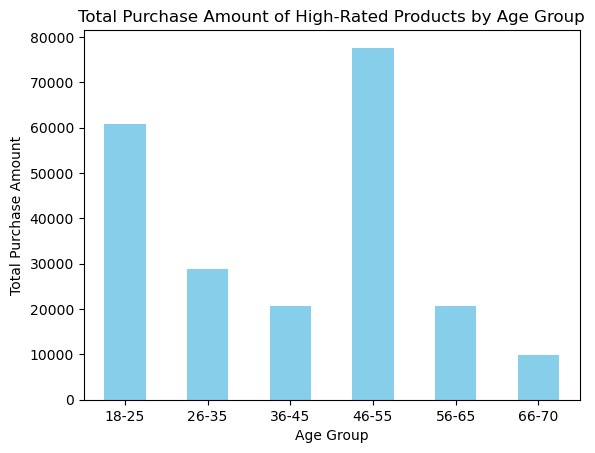

In [8]:
# Since 'filtered_data' already contains only ratings >= 4.5,
# we don't need to filter again.
high_rated_products = filtered_data.copy()

# Group by age group and calculate the TOTAL purchase amount
# (use sum, not count)
age_group_high_rated = high_rated_products.groupby('age_group')['total_purchases'].sum()
print(age_group_high_rated)

# Plot: total purchase amount by age group
age_group_high_rated.plot(kind='bar', color='skyblue')  # Color fine in your own environment
plt.title('Total Purchase Amount of High-Rated Products by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Purchase Amount')
plt.xticks(rotation=0)
plt.show()

product_category age_group    Books  Clothing  Electronics  Grocery  \
0                    18-25  12344.0   11547.0      13392.0  11472.0   
1                    26-35   5573.0    5236.0       7318.0   5496.0   
2                    36-45   3671.0    3856.0       5787.0   3570.0   
3                    46-55  14934.0   15039.0      17675.0  15134.0   
4                    56-65   3674.0    3832.0       5564.0   4026.0   
5                    66-70   1704.0    1969.0       2672.0   1902.0   

product_category  Home Decor  
0                    12012.0  
1                     5096.0  
2                     3807.0  
3                    14814.0  
4                     3657.0  
5                     1703.0  


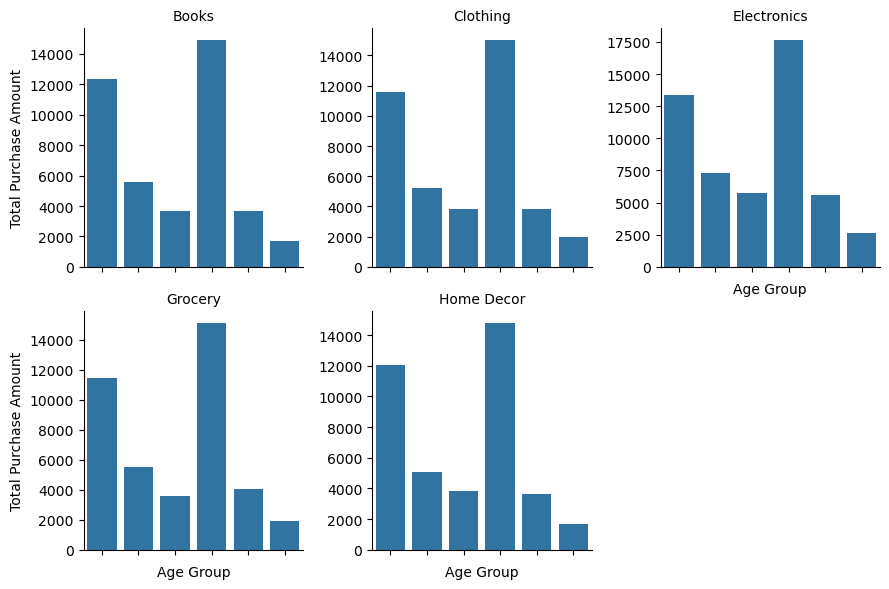

In [9]:
# ============================================================
# Analyze purchase amounts from different age groups by product
# category, specifically for high-rated products.
# ============================================================

# filtered_data already contains the necessary columns, so we just copy it.
# (Avoids chained assignment issues.)
high_rated_products = filtered_data.copy()

# Group by age group and product category.
# observed=False ensures consistent behavior and prevents FutureWarning.
# We use sum() instead of count() to match the idea of "purchase amount"
# If you meant "number of purchases", switch back to .count().
age_group_product_purchase = (
    high_rated_products
    .groupby(["age_group", "product_category"], observed=False)["total_purchases"]
    .sum()                     # Use .count() if you truly want counts
    .unstack(fill_value=0)     # Converts rows → columns and fills any missing categories with 0
    .reset_index()
)

print(age_group_product_purchase)

# Convert to long format for seaborn's FacetGrid
df_long = age_group_product_purchase.melt(
    id_vars=["age_group"],
    value_vars=["Books", "Clothing", "Electronics", "Grocery", "Home Decor"],
    var_name="product_category",
    value_name="total_purchases"
)

# Plot: separate bar charts for each product category by age group
g = sns.FacetGrid(df_long, col="product_category", col_wrap=3, sharey=False)
g.map_dataframe(
    sns.barplot,
    x="age_group",
    y="total_purchases",
    order=['18-25', '26-35', '36-45', '46-55', '56-65', '66-70']
)

# Improve axis labels & titles
g.set_titles("{col_name}")
g.set_axis_labels("Age Group", "Total Purchase Amount")
g.set_xticklabels(rotation=45)

plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# Chi-Square Test:
# Determines whether there is a significant association between
# age group and product category purchase frequency.
# ============================================================

from scipy.stats import chi2_contingency

# Ensure the table has age groups as rows and product categories as columns
# Remove the 'age_group' index column if present
contingency_table = (
    age_group_product_purchase
    .set_index('age_group')     # age_group becomes index
    .fillna(0)                  # ensure no missing values (important for chi-square)
)

# Print the actual contingency table
print("Contingency Table (Observed Frequencies):")
print(contingency_table)

# Convert to numpy array for the chi-square function
observed = contingency_table.values

# Perform the chi-square test
chi2_stat, p_val, dof, expected = chi2_contingency(observed)

# Print statistical results
print(f"\nChi-Square Value: {chi2_stat:.4f}")
print(f"P-value: {p_val:.4f}")
print(f"Degrees of Freedom: {dof}")
print("\nExpected Frequencies Table:")
print(expected)

# Interpretation
if p_val < 0.05:
    print("\nConclusion: There IS a significant relationship between age group and product category purchase frequency.")
else:
    print("\nConclusion: There is NO significant relationship between age group and product category purchase frequency.")

Contingency Table (Observed Frequencies):
product_category    Books  Clothing  Electronics  Grocery  Home Decor
age_group                                                            
18-25             12344.0   11547.0      13392.0  11472.0     12012.0
26-35              5573.0    5236.0       7318.0   5496.0      5096.0
36-45              3671.0    3856.0       5787.0   3570.0      3807.0
46-55             14934.0   15039.0      17675.0  15134.0     14814.0
56-65              3674.0    3832.0       5564.0   4026.0      3657.0
66-70              1704.0    1969.0       2672.0   1902.0      1703.0

Chi-Square Value: 670.8332
P-value: 0.0000
Degrees of Freedom: 20

Expected Frequencies Table:
[[11654.0823706  11536.98526612 14576.78159615 11570.64025339
  11428.51051374]
 [ 5507.81825006  5452.47716454  6889.11071239  5468.3827972
   5401.21107582]
 [ 3968.18369066  3928.31244164  4963.35491313  3939.77187426
   3891.37708032]
 [14881.59980959 14732.0734726  18613.72035372 14775.04897563
 

Contingency Table Used for Heatmap:
product_category    Books  Clothing  Electronics  Grocery  Home Decor
age_group                                                            
18-25             12344.0   11547.0      13392.0  11472.0     12012.0
26-35              5573.0    5236.0       7318.0   5496.0      5096.0
36-45              3671.0    3856.0       5787.0   3570.0      3807.0
46-55             14934.0   15039.0      17675.0  15134.0     14814.0
56-65              3674.0    3832.0       5564.0   4026.0      3657.0
66-70              1704.0    1969.0       2672.0   1902.0      1703.0


<Figure size 1000x600 with 0 Axes>

<Axes: xlabel='product_category', ylabel='age_group'>

Text(0.5, 1.0, 'Purchase Amount Heatmap')

Text(0.5, 36.72222222222221, 'Product Category')

Text(95.72222222222221, 0.5, 'Age Group')

(array([0.5, 1.5, 2.5, 3.5, 4.5]),
 [Text(0.5, 0, 'Books'),
  Text(1.5, 0, 'Clothing'),
  Text(2.5, 0, 'Electronics'),
  Text(3.5, 0, 'Grocery'),
  Text(4.5, 0, 'Home Decor')])

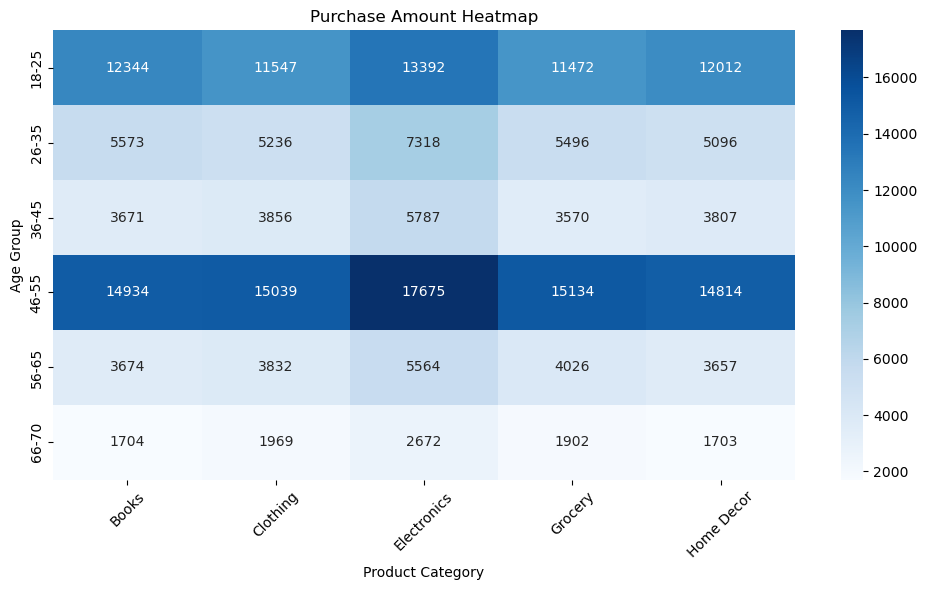

In [11]:
# ============================================================
# Heatmap Visualization:
# Shows the purchase amounts for each age group across product
# categories using a contingency table.
# ============================================================

# Make sure the contingency table is in DataFrame form and still labeled.
# If contingency_table is already a DataFrame (from previous code), we keep it as-is.
# If it's a numpy array, rebuild it properly.
if not isinstance(contingency_table, pd.DataFrame):
    contingency_df = pd.DataFrame(
        contingency_table,
        index=age_group_product_purchase['age_group'].unique(),
        columns=age_group_product_purchase.columns[1:]
    )
else:
    contingency_df = contingency_table.copy()

# Print the contingency table being plotted (useful for debugging)
print("Contingency Table Used for Heatmap:")
print(contingency_df)

# Create the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(contingency_df, annot=True, cmap='Blues', fmt='.0f')

plt.title("Purchase Amount Heatmap")
plt.xlabel("Product Category")
plt.ylabel("Age Group")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

DecisionTreeRegressor(random_state=42)

Feature Importance:
                         Feature  Importance
0                age_group_18-25    0.399090
3                age_group_46-55    0.120337
2                age_group_36-45    0.115353
6         product_category_Books    0.094779
7      product_category_Clothing    0.079054
10   product_category_Home Decor    0.043077
4                age_group_56-65    0.042694
8   product_category_Electronics    0.038024
1                age_group_26-35    0.026088
9       product_category_Grocery    0.025737
5                age_group_66-70    0.015766

Mean Squared Error: 8.0120


<Figure size 800x600 with 0 Axes>

C:\Users\Decagon Laptop\AppData\Local\Temp\ipykernel_15564\2222502094.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


<Axes: xlabel='Importance', ylabel='Feature'>

Text(0.5, 1.0, 'Feature Importance in Predicting Purchase Frequency')

Text(0.5, 0, 'Importance')

Text(0, 0.5, 'Feature')

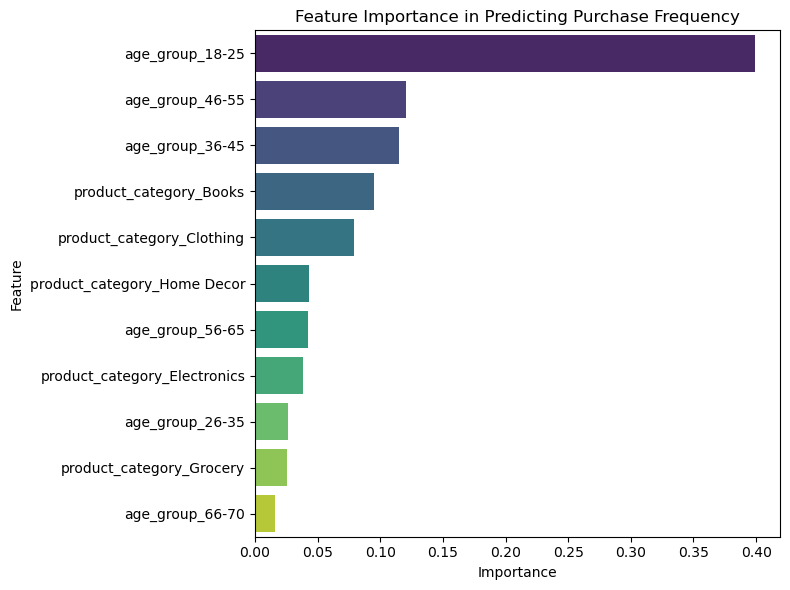

In [12]:
# ============================================================
# Predicting purchase frequency using age group & product category
# Decision Tree Regression + One-Hot Encoding
# ============================================================

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------------------
# 1. Select features (X) and target (y)
# -----------------------------------------
# age_group and product_category are categorical → must be encoded
X = filtered_data[['age_group', 'product_category']]
y = filtered_data['total_purchases']

# -----------------------------------------
# 2. One-Hot Encode categorical variables
# -----------------------------------------
# sparse_output=False replaces deprecated sparse=False in sklearn 1.4+
encoder = OneHotEncoder(sparse_output=False)

# Fit encoder on X and transform into numerical matrix
X_encoded = encoder.fit_transform(X)

# Convert encoded matrix into a DataFrame with readable column names
X_encoded_df = pd.DataFrame(
    X_encoded,
    columns=encoder.get_feature_names_out(['age_group', 'product_category']),
    index=X.index  # keep row alignment with y
)

# Replace X with encoded version
X = X_encoded_df

# -----------------------------------------
# 3. Train-Test Split
# -----------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# -----------------------------------------
# 4. Train Decision Tree Model
# -----------------------------------------
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

# -----------------------------------------
# 5. Feature Importance
# -----------------------------------------
feature_importance = model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

print("Feature Importance:")
print(importance_df)

# -----------------------------------------
# 6. Model Evaluation (MSE)
# -----------------------------------------
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"\nMean Squared Error: {mse:.4f}")

# -----------------------------------------
# 7. Visualization: Feature Importance
# -----------------------------------------
plt.figure(figsize=(8, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df,
    palette='viridis'
)

plt.title('Feature Importance in Predicting Purchase Frequency')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

RandomForestRegressor(random_state=42)

Random Forest Feature Importance:
                         Feature  Importance
0                age_group_18-25    0.310991
3                age_group_46-55    0.097588
10   product_category_Home Decor    0.092501
6         product_category_Books    0.087544
7      product_category_Clothing    0.079407
8   product_category_Electronics    0.070417
2                age_group_36-45    0.066344
5                age_group_66-70    0.052749
1                age_group_26-35    0.048970
4                age_group_56-65    0.047617
9       product_category_Grocery    0.045872

Random Forest Mean Squared Error: 8.0114


<Figure size 800x600 with 0 Axes>

C:\Users\Decagon Laptop\AppData\Local\Temp\ipykernel_15564\1228712772.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


<Axes: xlabel='Importance', ylabel='Feature'>

Text(0.5, 1.0, 'Random Forest Feature Importance')

Text(0.5, 0, 'Importance')

Text(0, 0.5, 'Feature')

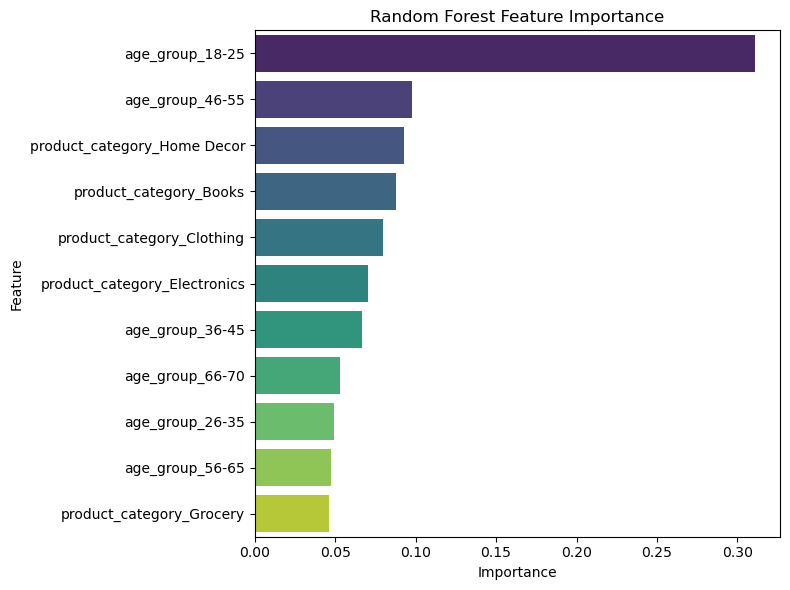

In [13]:
# ===============================================================
# Random Forest Regression:
# Predicting total purchase amount using age group + product type
# ===============================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# 1. Select features and target
# ---------------------------------------------------------------
X = filtered_data[['age_group', 'product_category']]
y = filtered_data['total_purchases']

# ---------------------------------------------------------------
# 2. One-Hot Encode categorical features
# ---------------------------------------------------------------
# Use sparse_output=False (new recommended argument)
encoder = OneHotEncoder(sparse_output=False)

# Fit + transform into encoded numerical matrix
X_encoded = encoder.fit_transform(X)

# Convert to a labeled DataFrame
X_encoded_df = pd.DataFrame(
    X_encoded,
    columns=encoder.get_feature_names_out(['age_group', 'product_category']),
    index=X.index  # keep alignment with y
)

X = X_encoded_df  # replace original X with the encoded version

# ---------------------------------------------------------------
# 3. Train/Test Split
# ---------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# ---------------------------------------------------------------
# 4. Train Random Forest Model
# ---------------------------------------------------------------
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

# ---------------------------------------------------------------
# 5. Feature Importance
# ---------------------------------------------------------------
feature_importance_rf = rf_model.feature_importances_

importance_rf_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importance_rf
}).sort_values(by='Importance', ascending=False)

print("Random Forest Feature Importance:")
print(importance_rf_df)

# ---------------------------------------------------------------
# 6. Model Evaluation (MSE)
# ---------------------------------------------------------------
y_pred_rf = rf_model.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)

print(f"\nRandom Forest Mean Squared Error: {mse_rf:.4f}")

# ---------------------------------------------------------------
# 7. Visualize Feature Importance
# ---------------------------------------------------------------
plt.figure(figsize=(8, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_rf_df,
    palette='viridis'
)

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

Text(0.0, 6172.0, '12344')

Text(1.0, 2786.5, '5573')

Text(2.0, 1835.5, '3671')

Text(3.0, 7467.0, '14934')

Text(4.0, 1837.0, '3674')

...

Text(5.0, 9098.5, '1703')

Text(0.5, 1.0, 'Total Purchases Amount by Age Group and Product Category')

Text(0.5, 0, 'Age Group')

Text(0, 0.5, 'Total Purchases Amount')

(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, '18-25'),
  Text(1, 0, '26-35'),
  Text(2, 0, '36-45'),
  Text(3, 0, '46-55'),
  Text(4, 0, '56-65'),
  Text(5, 0, '66-70')])

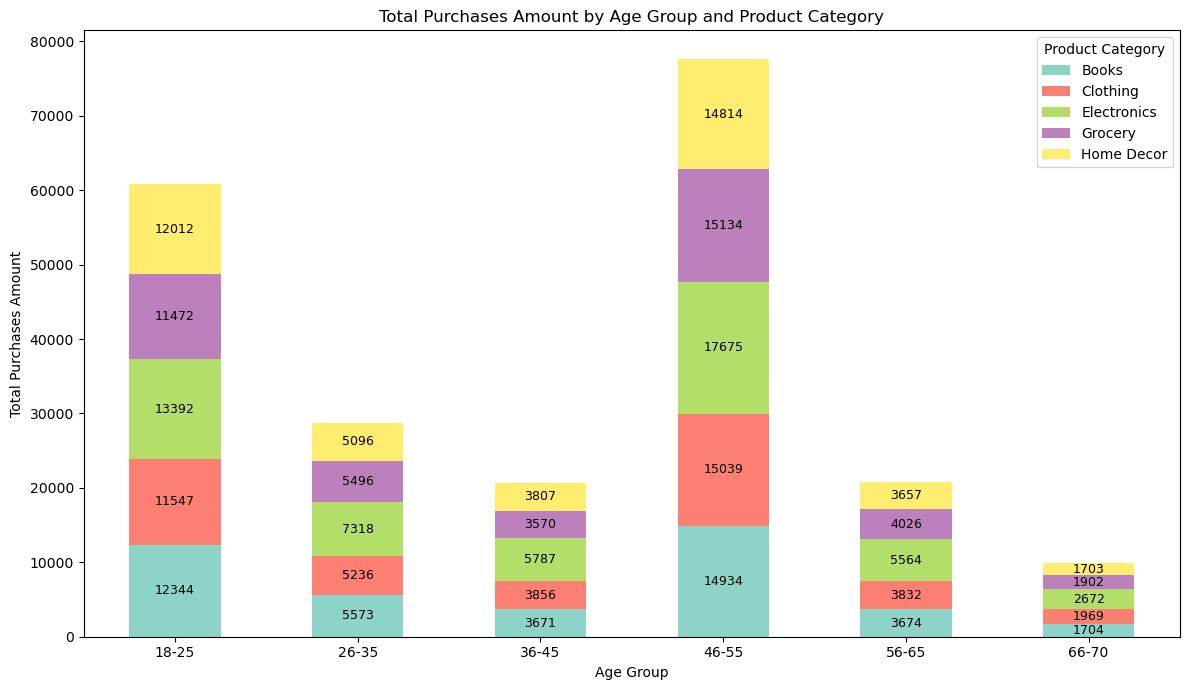

In [14]:
# ============================================================
# Stacked Bar Chart:
# Shows total purchases by age group across product categories.
# ============================================================

# Set age_group as index for plotting
plot_df = age_group_product_purchase.set_index('age_group')

# Create stacked bar chart
ax = plot_df.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 7),
    colormap='Set3'   # Good qualitative colormap
)

# ------------------------------------------------------------
# Annotate bar segments with their values
# ------------------------------------------------------------
for patch in ax.patches:
    height = patch.get_height()
    
    # Skip annotations for zero-height segments (avoids clutter)
    if height <= 0:
        continue
    
    x = patch.get_x() + patch.get_width() / 2
    y = patch.get_y() + height / 2
    
    ax.annotate(
        f'{height:.0f}',    # No decimals
        (x, y),
        ha='center',
        va='center',
        fontsize=9,
        color='black'
    )

# ------------------------------------------------------------
# Chart formatting
# ------------------------------------------------------------
plt.title('Total Purchases Amount by Age Group and Product Category')
plt.xlabel('Age Group')
plt.ylabel('Total Purchases Amount')
plt.xticks(rotation=0)
plt.legend(title='Product Category')
plt.tight_layout()
plt.show()

# Hypothesis 2

Male Spending Sample:
 0     324.086270
2    1063.432799
3    2466.854021
7      46.588070
9    3976.112295
Name: total_amount, dtype: float64

Female Spending Sample:
 1      806.707815
5     1185.167224
6      630.115295
10     363.927479
11     364.830567
Name: total_amount, dtype: float64

Male Spending Statistics:
Min: 10.00
Max: 4421.99
Average: 1324.15
Median: 1020.77

Female Spending Statistics:
Min: 10.06
Max: 4422.00
Average: 1326.74
Median: 1024.03

T-Statistic: -0.5854
P-Value: 0.5583
Conclusion: There is no statistically significant difference in average spending between genders.


<Figure size 800x600 with 0 Axes>

C:\Users\Decagon Laptop\AppData\Local\Temp\ipykernel_15564\3346984205.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


<Axes: xlabel='gender', ylabel='total_amount'>

Text(0.5, 1.0, 'Distribution of Total Amount by Gender')

Text(0.5, 0, 'Gender')

Text(0, 0.5, 'Total Amount')

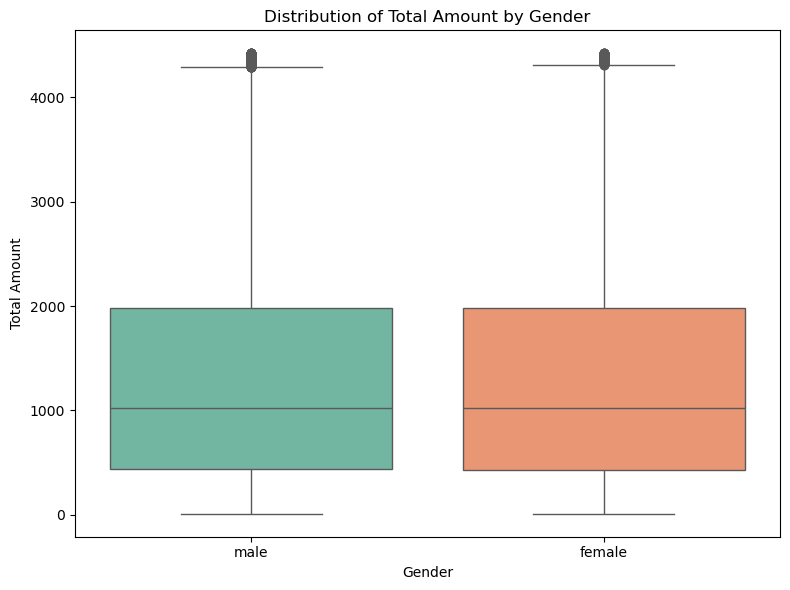

In [15]:
# ===============================================================
# 1. Gender-based Spending Analysis
#    - Data cleaning for gender column
#    - Summary statistics for male vs female spending
#    - Welch’s t-test (unequal variances)
#    - Boxplot visualization
# ===============================================================

from scipy.stats import ttest_ind
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# ---------------------------------------------------------------
# 1. Clean and standardize gender values
# ---------------------------------------------------------------
# Remove spaces, lowercase, ensure consistent category labeling
df['gender'] = df['gender'].astype(str).str.strip().str.lower()

# Filter only valid gender categories (avoids errors if unexpected values exist)
df_filtered_gender = df[df['gender'].isin(['male', 'female'])].copy()

# ---------------------------------------------------------------
# 2. Separate spending amounts by gender
# ---------------------------------------------------------------
male_spending = df_filtered_gender[df_filtered_gender['gender'] == 'male']['total_amount']
female_spending = df_filtered_gender[df_filtered_gender['gender'] == 'female']['total_amount']

print("Male Spending Sample:\n", male_spending.head())
print("\nFemale Spending Sample:\n", female_spending.head())

# ---------------------------------------------------------------
# 3. Summary statistics for each gender
# ---------------------------------------------------------------
male_stats = male_spending.describe()[['min', 'max', 'mean', '50%']]
female_stats = female_spending.describe()[['min', 'max', 'mean', '50%']]

print("\nMale Spending Statistics:")
print(f"Min: {male_stats['min']:.2f}")
print(f"Max: {male_stats['max']:.2f}")
print(f"Average: {male_stats['mean']:.2f}")
print(f"Median: {male_stats['50%']:.2f}")

print("\nFemale Spending Statistics:")
print(f"Min: {female_stats['min']:.2f}")
print(f"Max: {female_stats['max']:.2f}")
print(f"Average: {female_stats['mean']:.2f}")
print(f"Median: {female_stats['50%']:.2f}")

# ---------------------------------------------------------------
# 4. Welch’s t-test (safer when variances differ between groups)
# ---------------------------------------------------------------
t_stat, p_value = ttest_ind(
    male_spending,
    female_spending,
    equal_var=False
)

print(f"\nT-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print("Conclusion: The difference in average spending between genders is statistically significant.")
else:
    print("Conclusion: There is no statistically significant difference in average spending between genders.")

# ---------------------------------------------------------------
# 5. Boxplot: Visual comparison of spending distribution
# ---------------------------------------------------------------
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df_filtered_gender,
    x='gender',
    y='total_amount',
    palette='Set2'
)

plt.title('Distribution of Total Amount by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Amount')
plt.tight_layout()
plt.show()

Observed Frequency Table:
product_category  Books  Clothing  Electronics  Grocery  Home Decor
gender                                                             
female            17457     17437        20478    21358       17303
male              27560     27790        38627    33583       27369

Chi-Squared Test Results:
Chi-Squared Statistic: 322.7654
P-Value: 0.0000
Degrees of Freedom: 4

Expected Frequencies Table:
product_category         Books      Clothing   Electronics       Grocery  \
gender                                                                     
female            17002.930411  17082.247455  22323.970988  20751.227308   
male              28014.069589  28144.752545  36781.029012  34189.772692   

product_category    Home Decor  
gender                          
female            16872.623838  
male              27799.376162  

Conclusion: The relationship between gender and product category is statistically significant.

Proportion of Purchases in Each Category b

<Figure size 1200x800 with 0 Axes>

<Axes: xlabel='product_category', ylabel='proportion'>

Text(0.5, 1.0, 'Proportion of Purchases in Each Product Category by Gender')

Text(0.5, 0, 'Product Category')

Text(0, 0.5, 'Proportion')

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Books'),
  Text(1, 0, 'Clothing'),
  Text(2, 0, 'Electronics'),
  Text(3, 0, 'Grocery'),
  Text(4, 0, 'Home Decor')])

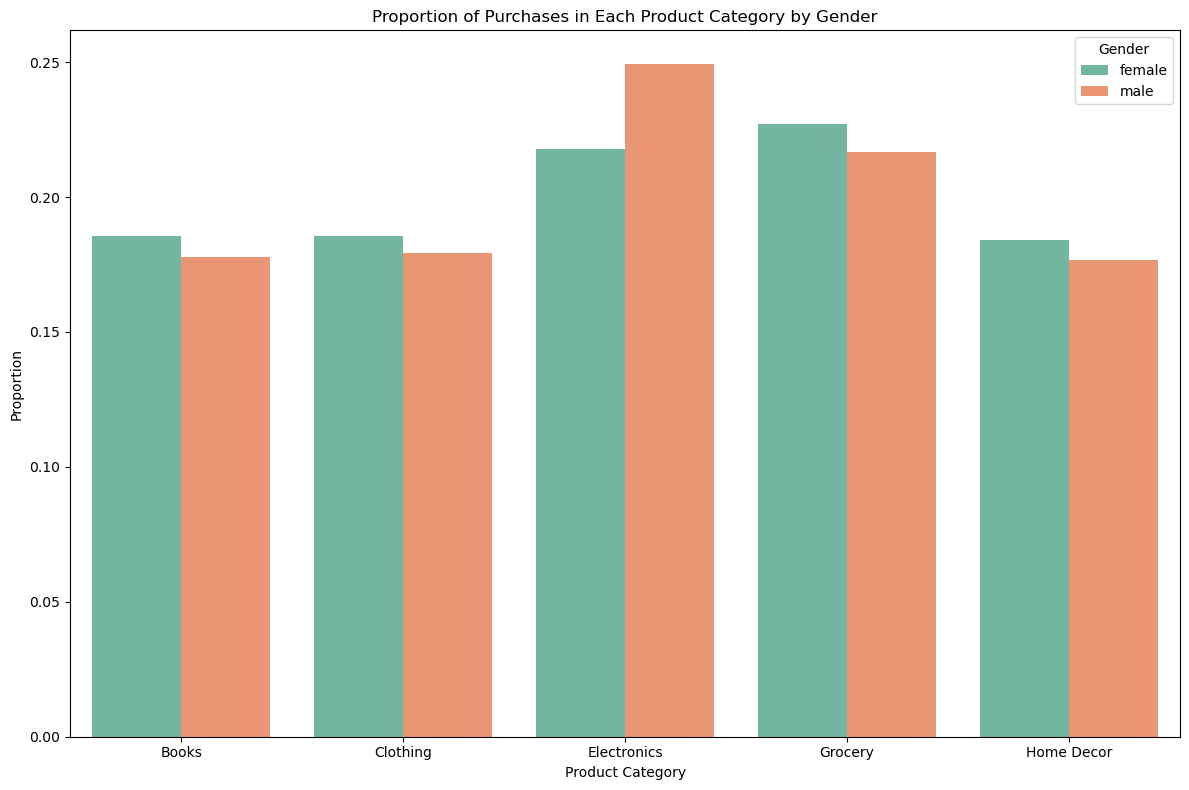

In [16]:
# ===============================================================
# 2.(2) Chi-Square Test:
#     - Gender vs Product Category association
#     - Proportion table
#     - Bar chart of proportions
# ===============================================================

from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# ---------------------------------------------------------------
# 1. Clean gender values (very important for consistent grouping)
# ---------------------------------------------------------------
df['gender'] = df['gender'].astype(str).str.strip().str.lower()
df_clean = df[df['gender'].isin(['male', 'female'])].copy()

# ---------------------------------------------------------------
# 2. Cross-tabulation (Observed Frequency Table)
# ---------------------------------------------------------------
cross_tab = pd.crosstab(df_clean['gender'], df_clean['product_category'])

print("Observed Frequency Table:")
print(cross_tab)

# ---------------------------------------------------------------
# 3. Chi-Square Test of Independence
# ---------------------------------------------------------------
chi2, p, dof, expected = chi2_contingency(cross_tab)

print("\nChi-Squared Test Results:")
print(f"Chi-Squared Statistic: {chi2:.4f}")
print(f"P-Value: {p:.4f}")
print(f"Degrees of Freedom: {dof}")

# Expected frequencies as a DataFrame
expected_df = pd.DataFrame(expected, index=cross_tab.index, columns=cross_tab.columns)
print("\nExpected Frequencies Table:")
print(expected_df)

# ---------------------------------------------------------------
# 4. Interpretation
# ---------------------------------------------------------------
alpha = 0.05
if p < alpha:
    print("\nConclusion: The relationship between gender and product category is statistically significant.")
else:
    print("\nConclusion: There is NO statistically significant relationship between gender and product category.")

# ---------------------------------------------------------------
# 5. Proportion of purchases in each category by gender
# ---------------------------------------------------------------
proportion_table = cross_tab.div(cross_tab.sum(axis=1), axis=0)

print("\nProportion of Purchases in Each Category by Gender:")
print(proportion_table)

# ---------------------------------------------------------------
# 6. Convert proportions to long format for plotting
# ---------------------------------------------------------------
proportion_long = (
    proportion_table
    .reset_index()
    .melt(id_vars='gender', var_name='product_category', value_name='proportion')
)

# ---------------------------------------------------------------
# 7. Barplot of gender proportions by product category
# ---------------------------------------------------------------
plt.figure(figsize=(12, 8))
sns.barplot(
    data=proportion_long,
    x='product_category',
    y='proportion',
    hue='gender',
    palette='Set2'
)

plt.title('Proportion of Purchases in Each Product Category by Gender')
plt.xlabel('Product Category')
plt.ylabel('Proportion')
plt.legend(title='Gender')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Observed Frequency Table:
product_brand  Adidas  Apple  Bed Bath & Beyond  Bluestar  Coca-Cola  \
gender                                                                 
female           5765   5824               5763       744       5895   
male             9229   9157               9209      1121       9300   

product_brand  Harpercollins  Home Depot  Ikea  Mitsubhisi  Nestle  Nike  \
gender                                                                     
female                  5682        5825  5710        2212    5814  5760   
male                    9387        9067  9093        3395    9094  9194   

product_brand  Penguin Books  Pepsi  Random House  Samsung  Sony  Whirepool  \
gender                                                                        
female                  5894   9750          5876     5773  5832          0   
male                    9104  15338          9066     9346  9310       6148   

product_brand  Zara  
gender               
female         5914

<Figure size 1200x800 with 0 Axes>

<Axes: xlabel='gender', ylabel='product_brand'>

Text(0.5, 1.0, 'Popularity of Product Brands by Gender')

Text(0.5, 58.7222222222222, 'Gender')

Text(120.7222222222222, 0.5, 'Product Brand')

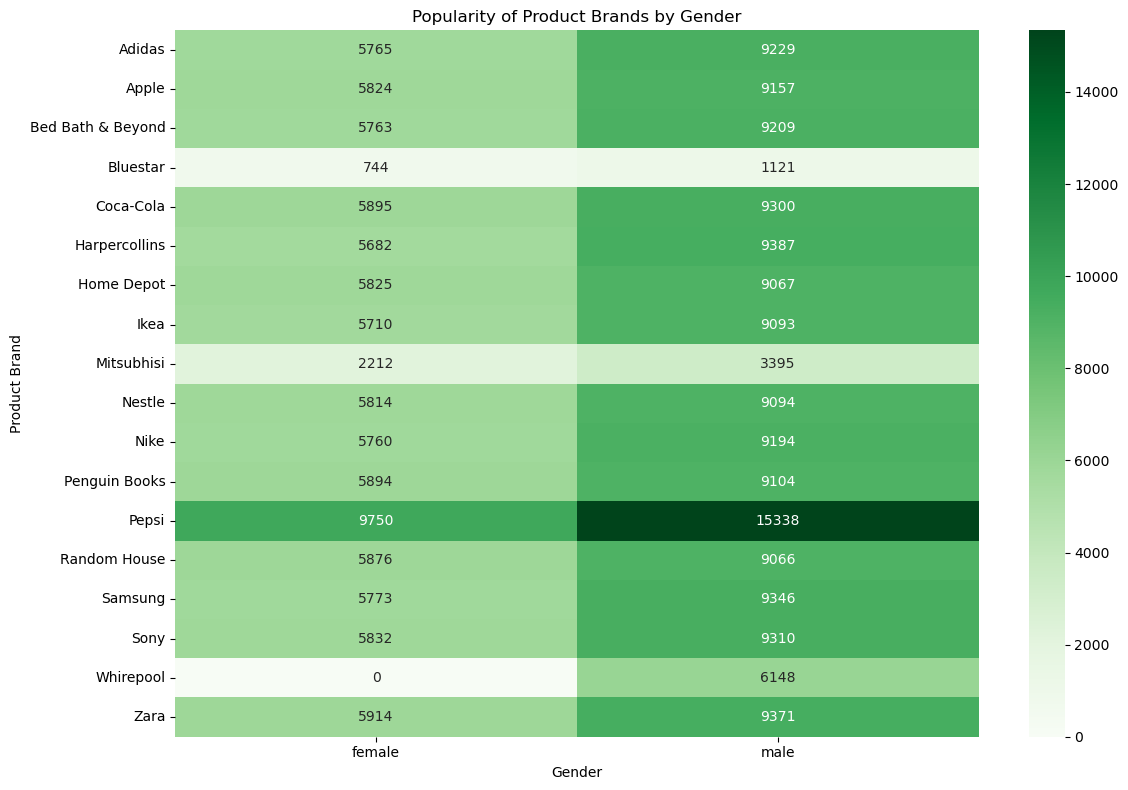

In [17]:
# ===============================================================
# 2.(3) Chi-Square Test:
#     Gender vs Product Brand
# ===============================================================

from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# ---------------------------------------------------------------
# 1. Clean gender values
# ---------------------------------------------------------------
df['gender'] = (
    df['gender']
    .astype(str)      # ensure string
    .str.strip()      # remove surrounding spaces
    .str.lower()      # convert to lowercase
)

# Keep only 'male' and 'female'
df_clean = df[df['gender'].isin(['male', 'female'])].copy()

# ---------------------------------------------------------------
# 2. Cross-tabulation (observed frequencies)
# ---------------------------------------------------------------
brand_cross_tab = pd.crosstab(df_clean['gender'], df_clean['product_brand'])
print("Observed Frequency Table:")
print(brand_cross_tab)

# ---------------------------------------------------------------
# 3. Perform Chi-Square Test
# ---------------------------------------------------------------
chi2, p, dof, expected = chi2_contingency(brand_cross_tab)

print("\nChi-Squared Test Results:")
print(f"Chi-Squared Statistic: {chi2:.4f}")
print(f"P-Value: {p:.4f}")
print(f"Degrees of Freedom: {dof}")

# Expected frequencies
expected_df = pd.DataFrame(expected, index=brand_cross_tab.index, columns=brand_cross_tab.columns)
print("\nExpected Frequencies Table:")
print(expected_df)

# ---------------------------------------------------------------
# 4. Interpretation
# ---------------------------------------------------------------
alpha = 0.05
if p < alpha:
    print("\nConclusion: There *is* a statistically significant relationship between gender and product brand.")
else:
    print("\nConclusion: There is *no* statistically significant relationship between gender and product brand.")

# ---------------------------------------------------------------
# 5. Heatmap of brand popularity by gender
# ---------------------------------------------------------------
brand_gender_ct = pd.crosstab(df_clean['product_brand'], df_clean['gender'])

plt.figure(figsize=(12, 8))
sns.heatmap(brand_gender_ct, annot=True, fmt='d', cmap='Greens')
plt.title('Popularity of Product Brands by Gender')
plt.xlabel('Gender')
plt.ylabel('Product Brand')
plt.tight_layout()
plt.show()

In [18]:
# ===============================================================
# 2.(1) Multinomial Logistic Regression:
#       - Predict Product Category from Gender
#       - Predict Product Brand from Gender
# ===============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# ---------------------------------------------------------------
# 1. Clean and encode gender values
# ---------------------------------------------------------------
df['gender'] = (
    df['gender']
    .astype(str)
    .str.strip()
    .str.lower()
)

# Keep only valid genders
df_clean = df[df['gender'].isin(['male', 'female'])].copy()

# Map gender to numeric form: male=1, female=0
df_clean.loc[:, 'gender_encoded'] = df_clean['gender'].map({'male': 1, 'female': 0})

# ---------------------------------------------------------------
# 2. Encode product category (dependent variable)
# ---------------------------------------------------------------
label_encoder_category = LabelEncoder()
df_clean.loc[:, 'product_category_encoded'] = label_encoder_category.fit_transform(
    df_clean['product_category']
)

# ---------------------------------------------------------------
# 3. Multinomial Logistic Regression — Product Category
# ---------------------------------------------------------------
multi_log_category = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000
)

multi_log_category.fit(df_clean[['gender_encoded']], df_clean['product_category_encoded'])

print("========== Product Category Multinomial Logistic Regression ==========")
print("Classes (Encoded):", label_encoder_category.classes_)
print("Coefficients (effect of gender):\n", multi_log_category.coef_)
print("Intercepts:\n", multi_log_category.intercept_)

# ---------------------------------------------------------------
# 4. Encode product brand
# ---------------------------------------------------------------
label_encoder_brand = LabelEncoder()
df_clean.loc[:, 'product_brand_encoded'] = label_encoder_brand.fit_transform(
    df_clean['product_brand']
)

# ---------------------------------------------------------------
# 5. Multinomial Logistic Regression — Product Brand
# ---------------------------------------------------------------
multi_log_brand = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000
)

multi_log_brand.fit(df_clean[['gender_encoded']], df_clean['product_brand_encoded'])

print("\n========== Product Brand Multinomial Logistic Regression ==========")
print("Classes (Encoded):", label_encoder_brand.classes_)
print("Coefficients (effect of gender):\n", multi_log_brand.coef_)
print("Intercepts:\n", multi_log_brand.intercept_)

C:\Anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial')

========== Product Category Multinomial Logistic Regression ==========
Classes (Encoded): ['Books' 'Clothing' 'Electronics' 'Grocery' 'Home Decor']
Coefficients (effect of gender):
 [[-0.03718771]
 [-0.0280515 ]
 [ 0.14202897]
 [-0.04102587]
 [-0.03576389]]
Intercepts:
 [-0.07029712 -0.07106052  0.08857692  0.13179976 -0.07901903]


C:\Anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial')


========== Product Brand Multinomial Logistic Regression ==========
Classes (Encoded): ['Adidas' 'Apple' 'Bed Bath & Beyond' 'Bluestar' 'Coca-Cola'
 'Harpercollins' 'Home Depot' 'Ikea' 'Mitsubhisi' 'Nestle' 'Nike'
 'Penguin Books' 'Pepsi' 'Random House' 'Samsung' 'Sony' 'Whirepool'
 'Zara']
Coefficients (effect of gender):
 [[-0.33976116]
 [-0.35853155]
 [-0.34174585]
 [-0.39408623]
 [-0.35500468]
 [-0.30726383]
 [-0.36885426]
 [-0.34513641]
 [-0.37055341]
 [-0.36377202]
 [-0.34286607]
 [-0.37696011]
 [-0.36000181]
 [-0.37805069]
 [-0.32823145]
 [-0.3428384 ]
 [ 6.02486627]
 [-0.35120834]]
Intercepts:
 [ 0.50845298  0.51899178  0.50797306 -1.54402899  0.53181683  0.49333253
  0.51945294  0.49878744 -0.45675807  0.51748309  0.5074873   0.53153278
  1.03598259  0.528514    0.50983708  0.52036714 -6.2638875   0.53466302]


DecisionTreeClassifier(max_depth=5, random_state=42)

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.00      0.00     18606
           1       0.63      1.00      0.77     31187

    accuracy                           0.63     49793
   macro avg       0.67      0.50      0.39     49793
weighted avg       0.66      0.63      0.48     49793

Accuracy Score: 0.6263932681300585
Confusion Matrix:
 [[    5 18601]
 [    2 31185]]


<Figure size 3000x1500 with 0 Axes>

[Text(0.5125, 0.9166666666666666, 'product_brand_Whirepool <= 0.5\ngini = 0.471\nsamples = 199169\nvalue = [75427.0, 123742.0]\nclass = Male'),
 Text(0.4625, 0.75, 'total_amount <= 14.611\ngini = 0.475\nsamples = 194256\nvalue = [75427.0, 118829.0]\nclass = Male'),
 Text(0.4875, 0.8333333333333333, 'True  '),
 Text(0.25, 0.5833333333333334, 'product_brand_Bed Bath & Beyond <= 0.5\ngini = 0.42\nsamples = 200\nvalue = [60, 140]\nclass = Male'),
 Text(0.15, 0.4166666666666667, 'product_brand_Coca-Cola <= 0.5\ngini = 0.407\nsamples = 190\nvalue = [54, 136]\nclass = Male'),
 Text(0.1, 0.25, 'product_brand_Penguin Books <= 0.5\ngini = 0.419\nsamples = 181\nvalue = [54, 127]\nclass = Male'),
 Text(0.05, 0.08333333333333333, 'gini = 0.431\nsamples = 169\nvalue = [53.0, 116.0]\nclass = Male'),
 Text(0.15, 0.08333333333333333, 'gini = 0.153\nsamples = 12\nvalue = [1, 11]\nclass = Male'),
 Text(0.2, 0.25, 'gini = 0.0\nsamples = 9\nvalue = [0, 9]\nclass = Male'),
 Text(0.35, 0.4166666666666667, 't

Text(0.5, 1.0, 'Decision Tree: Predicting Gender')

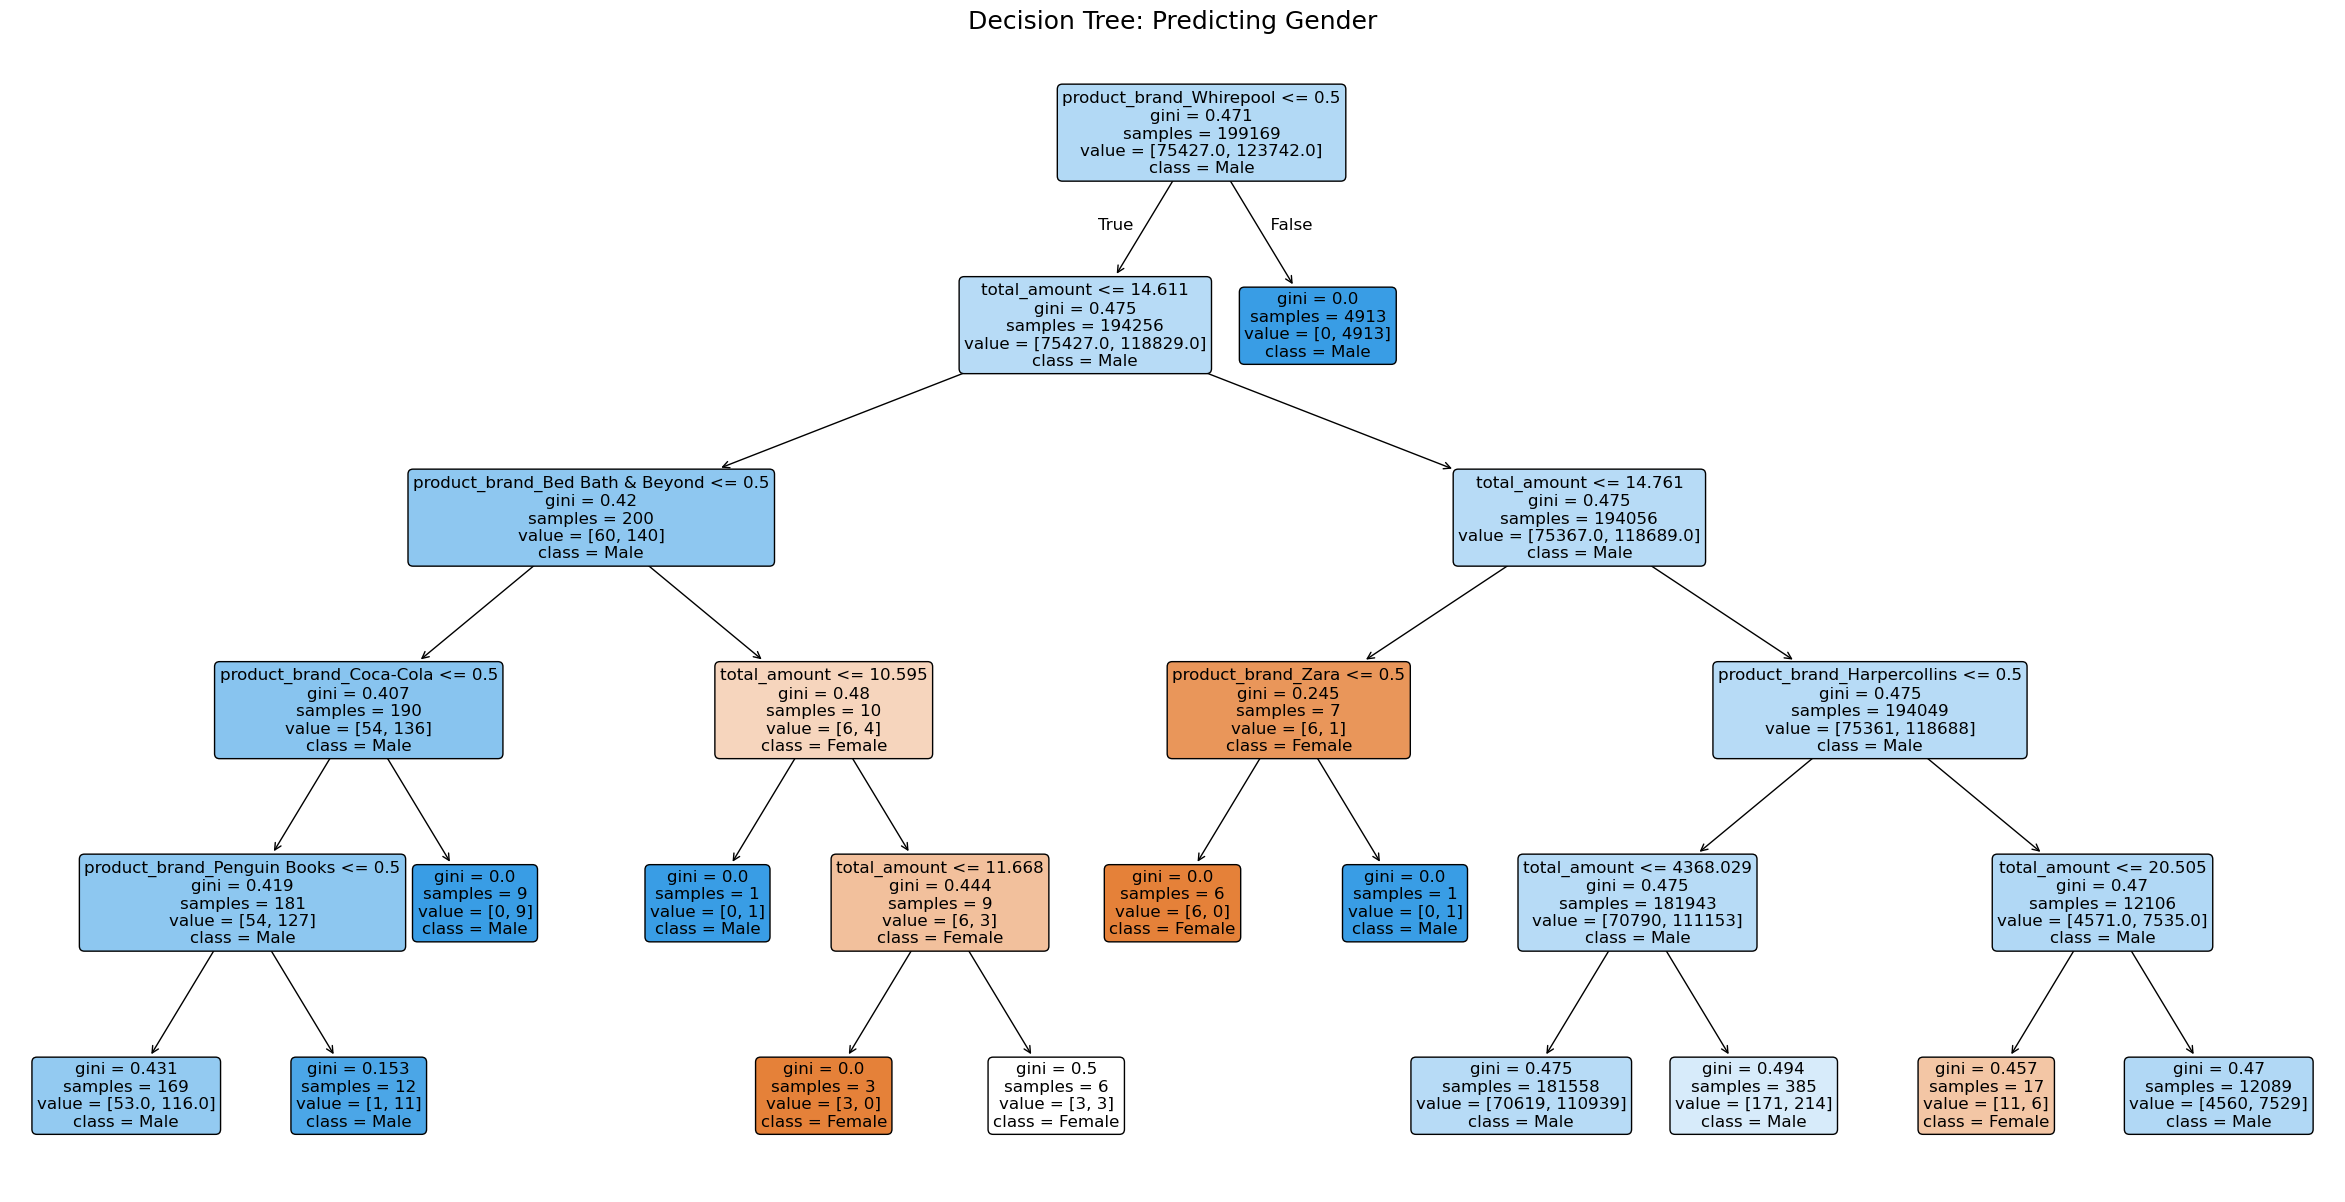

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# ======================================================
# 1. CLEAN GENDER COMPLETELY
# ======================================================
df['gender'] = (
    df['gender']
    .astype(str)
    .str.strip()
    .str.lower()
)

valid_genders = ['male', 'female']

df = df[df['gender'].isin(valid_genders)].copy()

# Encode gender as integer (important!)
df['gender'] = df['gender'].map({'male': 1, 'female': 0}).astype(int)


# ======================================================
# 2. KEEP ONLY REQUIRED COLUMNS
# ======================================================
required_cols = ['gender', 'total_amount', 'product_category', 'product_brand']

df = df[required_cols].dropna().copy()


# ======================================================
# 3. ONE-HOT ENCODE CATEGORY + BRAND
# ======================================================
df_encoded = pd.get_dummies(df, columns=['product_category', 'product_brand'], drop_first=True)


# ======================================================
# 4. BUILD FEATURES (X) + TARGET (y)
# ======================================================
feature_cols = [
    col for col in df_encoded.columns 
    if col.startswith('product_category_') or col.startswith('product_brand_')
]

# Add total_amount safely
X = df_encoded[feature_cols].copy()
X['total_amount'] = df_encoded['total_amount']

y = df_encoded['gender']  # Should be perfect 0/1 integers now


# ======================================================
# 5. TRAIN-TEST SPLIT
# ======================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ======================================================
# 6. TRAIN DECISION TREE
# ======================================================
dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train, y_train)


# ======================================================
# 7. EVALUATE
# ======================================================
y_pred = dt_model.predict(X_test)

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


# ======================================================
# 8. VISUALIZE TREE
# ======================================================
plt.figure(figsize=(30, 15))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=['Female', 'Male'],
    filled=True,
    rounded=True,
    fontsize=12
)
plt.title("Decision Tree: Predicting Gender", fontsize=18)
plt.show()

# Hypothesis 3

In [24]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.8/72.0 MB 2.2 MB/s eta 0:00:32
    --------------------------------------- 1.6/72.0 MB 3.0 MB/s eta 0:00:24
   - -------------------------------------- 2.9/72.0 MB 4.0 MB/s eta 0:00:18
   -- ------------------------------------- 4.2/72.0 MB 4.7 MB/s eta 0:00:15
   --- ------------------------------------ 5.8/72.0 MB 5.1 MB/s eta 0:00:13
   --- ------------------------------------ 7.1/72.0 MB 5.4 MB/s eta 0:00:12
   ---- ----------------------------------- 8.7/72.0 MB 5.7 MB/s eta 0:00:12
   ----- ---------------------------------- 10.0/72.0 MB 5.9 MB/s eta 0:00:11
   ------ ---------------

Missing values:
 transaction_id      0
customer_id         0
name                0
email               0
phone               0
address             0
city                0
state               0
zipcode             0
country             0
age                 0
gender              0
income              0
customer_segment    0
date                0
year                0
month               0
time                0
total_purchases     0
amount              0
dtype: int64


C:\Users\Decagon Laptop\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [11:35:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)


=== XGBoost Classification Report ===
              precision    recall  f1-score   support

           0       0.73      0.94      0.82     49732
           1       0.73      0.30      0.42     24957

    accuracy                           0.73     74689
   macro avg       0.73      0.62      0.62     74689
weighted avg       0.73      0.73      0.69     74689

ROC-AUC Score: 0.7029174262414536


<Figure size 800x500 with 0 Axes>

<BarContainer object of 9 artists>

Text(0.5, 0, 'Importance')

Text(0.5, 1.0, 'Feature Importance (XGBoost)')

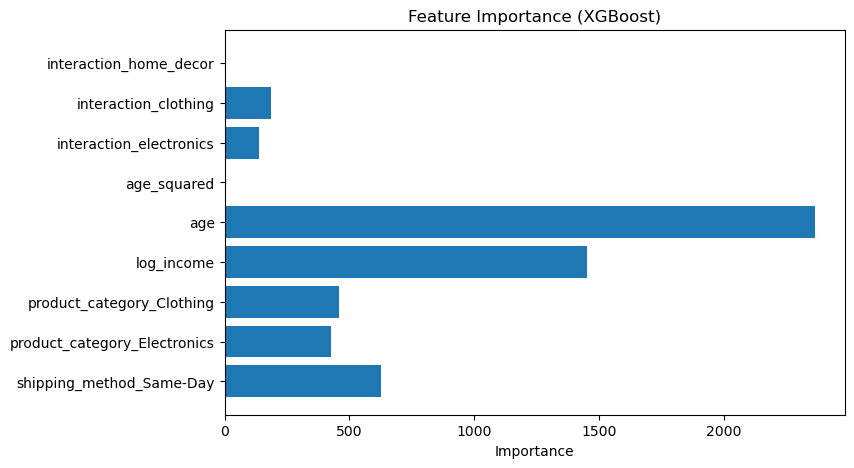


=== Shipping Method Group Counts ===
shipping_method_Same-Day
False    162798
True      86164
Name: count, dtype: int64

ANOVA Results: F_onewayResult(statistic=np.float64(101.26180373352278), pvalue=np.float64(8.144542537112282e-24))

Tukey HSD Results:
 Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower  upper  reject
-------------------------------------------------
 False   True   0.0442   0.0 0.0356 0.0528   True
-------------------------------------------------

Chi-square: 108.31809672253374
p-value: 2.525050441395896e-23
Cramér's V: 0.020858543434520396

=== OLS Regression Summary ===
                            OLS Regression Results                            
Dep. Variable:         feedback_score   R-squared:                       0.058
Model:                            OLS   Adj. R-squared:                  0.058
Method:                 Least Squares   F-statistic:                     2182.
Date:                Mon, 24 Nov 2025   Prob (F

C:\Anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])


<Figure size 600x400 with 0 Axes>

C:\Users\Decagon Laptop\AppData\Local\Temp\ipykernel_15564\2127474991.py:188: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[ship_col], y=df["feedback_score"], palette="Set2")


<Axes: xlabel='shipping_method_Same-Day', ylabel='feedback_score'>

Text(0.5, 1.0, 'Feedback Scores by Shipping Method')

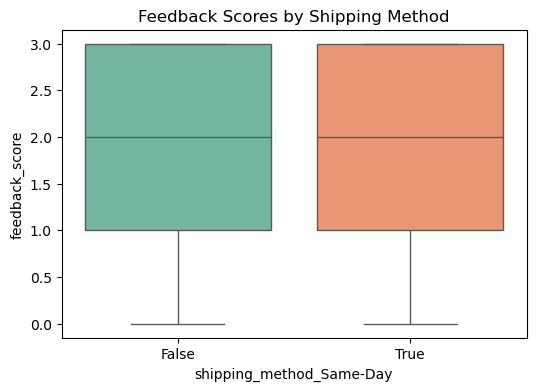

<Figure size 600x400 with 0 Axes>

Text(0.5, 1.0, 'Effect Size by Product Category')

Text(0, 0.5, 'Effect Size')

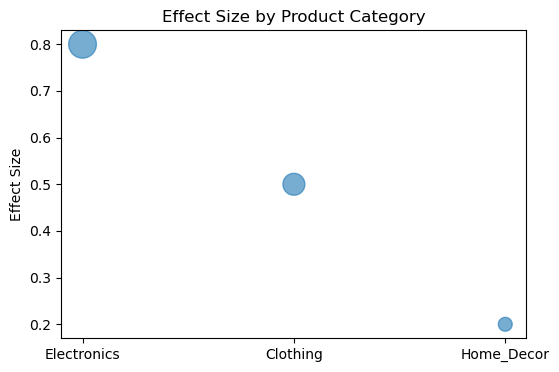

<Figure size 600x400 with 0 Axes>

<BarContainer object of 3 artists>

Text(0, 0.5, 'Predicted Probability of Excellent Feedback')

Text(0.5, 1.0, 'Predicted Probability by Product Category (Test Set)')

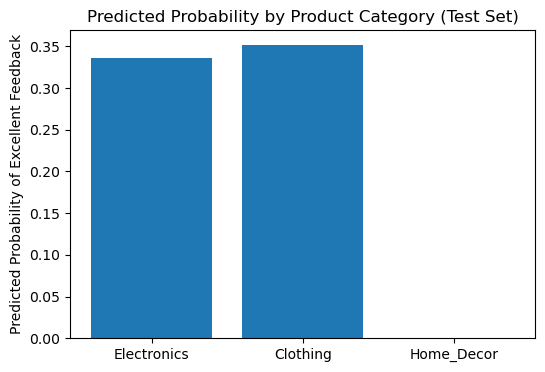

In [28]:
# ============================================================
# Full Analysis Pipeline (Cleaned + Corrected)
# - Loads cleaned_new_retail_data.csv
# - Data preparation
# - XGBoost classification
# - ANOVA + Tukey
# - Chi-square + Cramér's V
# - OLS regression
# - Visualizations
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from xgboost import XGBClassifier

from scipy.stats import f_oneway, chi2_contingency
from statsmodels.api import OLS, add_constant
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# ------------------------------------------------------------
# Step 1: Load Data & Preprocess
# ------------------------------------------------------------
df = pd.read_csv("cleaned_new_retail_data.csv")

# Clean column names (remove spaces & hyphens)
df.columns = (
    df.columns.str.strip()
              .str.replace(" ", "_")
              .str.replace("-", "_")
)

# Encode feedback -> numeric scale
feedback_mapping = {"Excellent": 3, "Good": 2, "Average": 1, "Bad": 0}
df["feedback_score"] = df["feedback"].map(feedback_mapping)

# Encode income -> numeric
income_mapping = {"Low": 1, "Medium": 2, "High": 3}
df["income"] = df["income"].map(income_mapping)

# One-hot encode shipping_method and product_category
for col in ["shipping_method", "product_category"]:
    if col in df.columns:
        df = pd.concat(
            [df, pd.get_dummies(df[col], prefix=col, drop_first=True)],
            axis=1
        )

# Standard expected dummy column names
ship_col = "shipping_method_Same-Day"
pc_elec = "product_category_Electronics"
pc_cloth = "product_category_Clothing"
pc_home = "product_category_Home_Decor"

# Create missing dummy columns if needed
for c in [ship_col, pc_elec, pc_cloth, pc_home]:
    if c not in df.columns:
        df[c] = 0

# Interaction terms
df["interaction_electronics"] = df[ship_col] * df[pc_elec]
df["interaction_clothing"]   = df[ship_col] * df[pc_cloth]
df["interaction_home_decor"] = df[ship_col] * df[pc_home]

# Transformations
df["log_income"] = np.log(df["income"].fillna(0) + 1)
df["age_squared"] = df["age"].astype(float) ** 2

print("Missing values:\n", df.isnull().sum().head(20))

# ------------------------------------------------------------
# Step 2: XGBoost Classification (Predict Excellent feedback)
# ------------------------------------------------------------
X_cols = [
    ship_col, pc_elec, pc_cloth,
    "log_income", "age", "age_squared",
    "interaction_electronics", "interaction_clothing", "interaction_home_decor"
]

X_cols = [c for c in X_cols if c in df.columns]

X = df[X_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
y = (df["feedback_score"] == 3).astype(int)   # 1 = Excellent

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Train XGBoost
xgb = XGBClassifier(
    eval_metric="logloss",
    use_label_encoder=False,
    random_state=42
)
xgb.fit(X_train, y_train)

# Predictions
y_pred = xgb.predict(X_test)
y_pred_proba = xgb.predict_proba(X_test)[:, 1]

print("\n=== XGBoost Classification Report ===")
print(classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))

# Safe universal feature importance extraction
booster = xgb.get_booster()
raw_importances = booster.get_score(importance_type="weight")

importance_list = [raw_importances.get(col, 0) for col in X.columns]

plt.figure(figsize=(8, 5))
plt.barh(X.columns, importance_list)
plt.xlabel("Importance")
plt.title("Feature Importance (XGBoost)")
plt.show()

# ------------------------------------------------------------
# Step 3: ANOVA + Tukey Post Hoc
# ------------------------------------------------------------
group_sizes = df[ship_col].value_counts()
print("\n=== Shipping Method Group Counts ===")
print(group_sizes)

if df[ship_col].nunique() < 2 or min(group_sizes) < 2:
    print("\n❗ ANOVA & Tukey skipped: shipping_method_Same_Day has no variation.")
else:
    group_same_day = df[df[ship_col] == 1]["feedback_score"].dropna()
    group_other = df[df[ship_col] == 0]["feedback_score"].dropna()

    anova_results = f_oneway(group_same_day, group_other)
    print("\nANOVA Results:", anova_results)

    tukey = pairwise_tukeyhsd(
        endog=df["feedback_score"],
        groups=df[ship_col],
        alpha=0.05
    )
    print("\nTukey HSD Results:\n", tukey.summary())

# ------------------------------------------------------------
# Step 4: Chi-Square + Cramér’s V
# ------------------------------------------------------------
ct = pd.crosstab(df[ship_col], df["feedback"])
chi2, p, dof, expected = chi2_contingency(ct)
n = ct.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

print("\nChi-square:", chi2)
print("p-value:", p)
print("Cramér's V:", cramers_v)

# ------------------------------------------------------------
# Step 5: OLS Regression (Predict feedback_score)
# ------------------------------------------------------------
reg_cols = [
    ship_col, pc_elec, pc_cloth, pc_home,
    "log_income", "age", "age_squared",
    "interaction_clothing", "interaction_home_decor"
]
reg_cols = [c for c in reg_cols if c in df.columns]

X_reg = df[reg_cols].apply(pd.to_numeric, errors='coerce').fillna(df[reg_cols].mean())
y_reg = df["feedback_score"].fillna(df["feedback_score"].mean())

# 🔥 FIX: convert all predictors AND target to float
X_reg = X_reg.astype(float)
y_reg = y_reg.astype(float)

# Fit OLS model
X_reg_const = add_constant(X_reg)
model = OLS(y_reg, X_reg_const).fit()

print("\n=== OLS Regression Summary ===")
print(model.summary())

print("\n=== OLS Regression Summary ===")
print(model.summary())

# ------------------------------------------------------------
# Step 6: Visualizations
# ------------------------------------------------------------
plt.figure(figsize=(6, 4))
sns.boxplot(x=df[ship_col], y=df["feedback_score"], palette="Set2")
plt.title("Feedback Scores by Shipping Method")
plt.show()

# Bubble chart (placeholder values)
effect_sizes = {"Electronics": 0.8, "Clothing": 0.5, "Home_Decor": 0.2}
plt.figure(figsize=(6, 4))
plt.scatter(effect_sizes.keys(), effect_sizes.values(),
            s=[v * 500 for v in effect_sizes.values()], alpha=0.6)
plt.title("Effect Size by Product Category")
plt.ylabel("Effect Size")
plt.show()

# ------------------------------------------------------------
# Step 7: Predicted Probability per Product Category
# ------------------------------------------------------------
df_test = df.loc[X_test.index]
categories = ["Electronics", "Clothing", "Home_Decor"]

# Create category columns if missing
for cat in categories:
    col = f"product_category_{cat}"
    if col not in df_test.columns:
        df_test[col] = 0

predicted_probs = []
for cat in categories:
    mask = df_test[f"product_category_{cat}"] == 1
    if mask.sum() > 0:
        predicted_probs.append(np.mean(y_pred_proba[mask]))
    else:
        predicted_probs.append(0)

plt.figure(figsize=(6, 4))
plt.bar(categories, predicted_probs)
plt.ylabel("Predicted Probability of Excellent Feedback")
plt.title("Predicted Probability by Product Category (Test Set)")
plt.show()